In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# Processed data load karo
df=pd.read_csv(r'D:\desert-agritech\data\processed\desert_hydroponic_processed.csv')

print("Shape:",df.shape)
df.head()

Shape: (5000, 15)


,temperature,humidity,soil_moisture,pH_level,light_hours,water_given_ml,nutrient_level,co2_ppm,day_number,yield_kg,water_stress,heat_stress_index,water_efficiency,pH_deviation,growth_score
0,42.490802,21.809066,42.418449,6.499340,11.839986,136.948336,63.814457,887.514105,27.902084,4.943280,0,33.223955,3.154151,0.000660,7.555623
1,54.014286,24.203070,39.974726,6.993494,7.476096,124.301492,45.929245,431.122774,9.533600,0.413325,1,40.941171,3.033614,0.493494,3.433714
2,49.639879,35.636422,30.569235,6.625334,8.773118,341.676780,96.449852,889.808273,12.372330,6.423662,1,31.950002,10.823094,0.125334,8.461659
3,46.973170,20.200132,56.436000,5.666605,11.306245,486.446529,21.897845,471.734885,17.260402,3.918849,1,37.484528,8.469366,0.833395,2.475824
4,38.120373,36.089491,48.597450,5.871160,9.856715,301.088524,58.785642,968.275391,19.328800,5.886870,0,24.362924,6.070645,0.628840,5.794333


In [2]:
#features (input)-jo model ko denge
X=df.drop(['yield_kg','water_stress'],axis=1)

#Target (output) - jo model predict karega
y=df['yield_kg']

print("Features Shape:",X.shape)
print("Target Shape:",y.shape)
print("\nFeatures list:")
print(X.columns.tolist())



Features Shape: (5000, 13)
Target Shape: (5000,)

Features list:
['temperature', 'humidity', 'soil_moisture', 'pH_level', 'light_hours', 'water_given_ml', 'nutrient_level', 'co2_ppm', 'day_number', 'heat_stress_index', 'water_efficiency', 'pH_deviation', 'growth_score']


In [3]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("Trainig Data:",X_train.shape)
print("Testing data:",X_test.shape)

Trainig Data: (4000, 13)
Testing data: (1000, 13)


In [4]:
#MOdel Banao
model=xgb.XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=6,random_state=42)

#now train the model
model.fit(X_train,y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [5]:
#check accuracy of model
y_pred=model.predict(X_test)

#accuracy metrices
r2=r2_score(y_test,y_pred)
rmse=mean_squared_error(y_test,y_pred)**0.5

print(f"R2 Score :{r2:.4f}")
print(f"RMSE :{rmse:.4f}")
print(f"\nModel Accuracy:{r2*100:.2f}%")

R2 Score :0.9250
RMSE :0.5467

Model Accuracy:92.50%


In [6]:
import joblib

#model save
joblib.dump(model,r'D:\desert-agritech\models\xgboost_yeild_model.pkl')
print("model Saved!")
print("Location : xgboost_yeild_model.pkl")

model Saved!
Location : xgboost_yeild_model.pkl


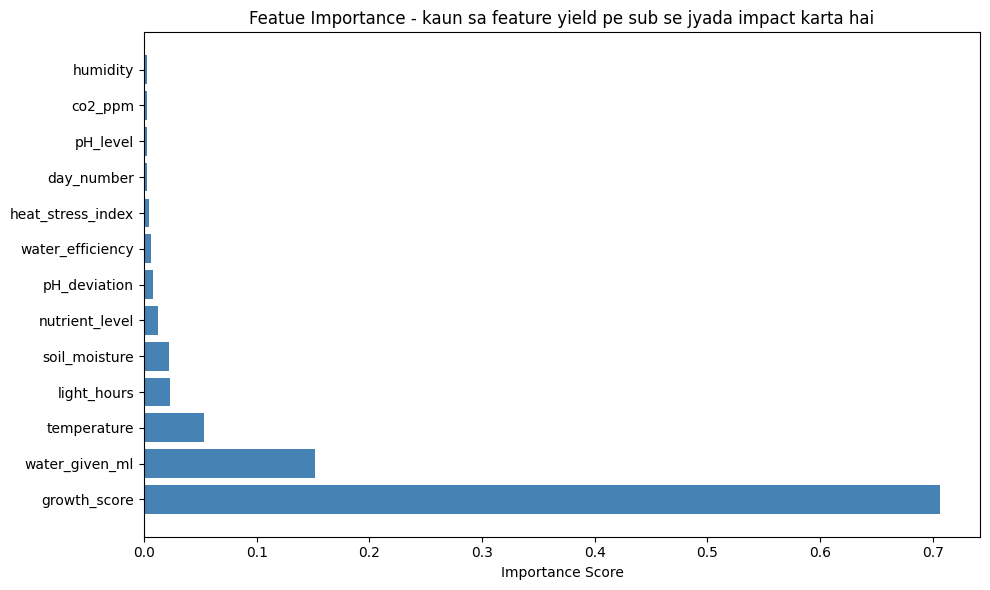


Top 3 important features:
1.growth_score->0.7066
2.water_given_ml->0.1518
3.temperature->0.0534


In [7]:
#Feature IMportant plot
plt.figure(figsize=(10,6))

importance = model.feature_importances_
features=X.columns

#sort karo
indices=importance.argsort()[::-1]

plt.barh(features[indices],importance[indices],color='steelblue')
plt.title('Featue Importance - kaun sa feature yield pe sub se jyada impact karta hai')
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig(r'd:\desert-agritech\data\processed\feature_importance.png')
plt.show()

print("\nTop 3 important features:")
for i in range(3):
    idx=indices[i]
    print(f"{i+1}.{features[idx]}->{importance[idx]:.4f}")